# Discovering Cognitive Models with SPICE — Solution

**Tutorial Duration: ~1.5 hours**

In this tutorial, you will learn how to use **SPICE** (Sparse and Interpretable Cognitive Equations) to automatically discover reinforcement learning models from behavioral data.

SPICE fits **ensembles** of recurrent neural networks (RNNs) to behavioral data and then extracts concise mathematical equations describing the learned dynamics using sparse equation discovery (SINDy).

### What you will learn:
1. How to prepare data for SPICE (CSV format → SpiceDataset)
2. Implementing and fitting SPICE models of increasing complexity
3. Inspecting and interpreting discovered equations
4. Parameter recovery across different agent types

### Tutorial structure
We'll build up complexity step by step, running the **full pipeline** for each level:

| Level | Mechanism | Pipeline |
|-------|-----------|----------|
| Basic | Rescorla-Wagner learning | Data → Model → Fit → Inspect |
| + Forgetting | Value decay for unchosen actions | Data → Model → Fit → Inspect |
| + Choice Perseverance | Repeat bias | Data → Model → Fit → Inspect |
| Recovery | Mixed agents, structural differences | Generate → Fit → Analyze |

### Prerequisites
- Basic Python & PyTorch familiarity
- Understanding of reinforcement learning (Q-learning, Rescorla-Wagner)
- `pip install autospice`

---
## Setup

In [13]:
# Uncomment if running on Google Colab:
# !pip uninstall -y numpy pandas
# !pip install numpy==1.26.4 pandas==2.2.2
# !pip install autospice

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


---
# Part 1: Data Format & The Bandit Task

## 1.1 The Two-Armed Bandit Task

In a two-armed bandit task, a participant repeatedly chooses between two options. Each option yields a **continuous reward** (between 0 and 1) drawn from a distribution centered on that option's mean reward. These means may drift over time, requiring the participant to continuously learn.

Let's first write a simulation of both the **environment** and a **Q-learning agent**.

In [2]:
def simulate_bandit_qlearning(
    n_participants: int = 1,
    n_blocks: int = 5,
    n_trials: int = 100,
    n_actions: int = 2,
    # Agent parameters
    alpha_reward: float = 0.3,
    alpha_penalty: float = None,
    forget_rate: float = 0.0,
    alpha_choice: float = 0.0,
    beta_reward: float = 3.0,
    beta_choice: float = 0.0,
    # Environment parameters
    drift_rate: float = 0.1,
    reward_noise: float = 0.15,
    q_init: float = 0.5,
):
    """Simulate a Q-learning agent on a drifting two-armed bandit with continuous rewards.
    
    Each participant plays n_blocks independent blocks (new reward schedule per block).
    Rewards are drawn from N(mean_reward, reward_noise), clipped to [0, 1].
    
    Returns:
        df: DataFrame with columns [participant, block, choice, reward]
        trajectories: dict with internal agent states for visualization (indexed by session)
    """
    if alpha_penalty is None:
        alpha_penalty = alpha_reward
    
    records = []
    trajectories = {'Q': [], 'C': [], 'reward_probs': [], 'choices': [], 'rewards': []}
    
    for participant in range(n_participants):
        for block in range(n_blocks):
            reward_means = np.random.uniform(0.2, 0.8, size=n_actions)
            Q = np.full(n_actions, q_init)
            C = np.zeros(n_actions)
            
            session_Q, session_C, session_rp = [], [], []
            session_choices, session_rewards = [], []
            
            for trial in range(n_trials):
                session_Q.append(Q.copy())
                session_C.append(C.copy())
                session_rp.append(reward_means.copy())
                
                # Action selection (softmax)
                logits = beta_reward * Q + beta_choice * C
                logits -= logits.max()
                probs = np.exp(logits) / np.exp(logits).sum()
                choice = np.random.choice(n_actions, p=probs)
                
                # Get continuous reward: Gaussian around mean, clipped to [0, 1]
                reward = np.clip(np.random.normal(reward_means[choice], reward_noise), 0.0, 1.0)
                
                session_choices.append(choice)
                session_rewards.append(reward)
                records.append({
                    'participant': participant, 'block': block,
                    'choice': choice, 'reward': reward,
                })
                
                # Q-value update (Rescorla-Wagner)
                prediction_error = reward - Q[choice]
                alpha = alpha_reward if prediction_error >= 0 else alpha_penalty
                Q[choice] += alpha * prediction_error
                
                # Forgetting for unchosen actions
                for a in range(n_actions):
                    if a != choice:
                        Q[a] += forget_rate * (q_init - Q[a])
                
                # Choice perseverance
                C[choice] += alpha_choice * (1.0 - C[choice])
                for a in range(n_actions):
                    if a != choice:
                        C[a] += alpha_choice * (0.0 - C[a])
                
                # Drift environment
                reward_means += np.random.normal(0, drift_rate, size=n_actions)
                reward_means = np.clip(reward_means, 0.05, 0.95)
            
            trajectories['Q'].append(np.array(session_Q))
            trajectories['C'].append(np.array(session_C))
            trajectories['reward_probs'].append(np.array(session_rp))
            trajectories['choices'].append(np.array(session_choices))
            trajectories['rewards'].append(np.array(session_rewards))
    
    return pd.DataFrame(records), trajectories

## 1.2 Visualizing the task and agent behavior

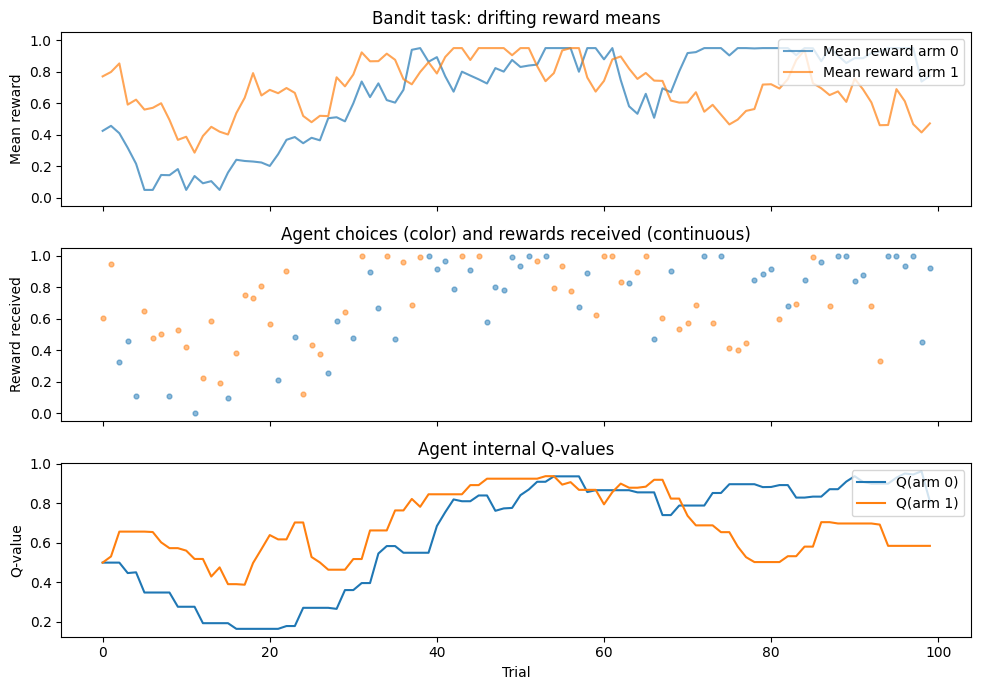

In [ ]:
# Generate data from a simple RW agent (1 participant, 5 blocks)
df_basic, traj_basic = simulate_bandit_qlearning(
    n_participants=100, n_blocks=5, n_trials=100,
    alpha_reward=0.3, beta_reward=3.0,
    drift_rate=0.2,
)

# Plot one example block
session_id = 0
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Top: Reward means (drifting)
ax = axes[0]
rp = traj_basic['reward_probs'][session_id]
ax.plot(rp[:, 0], 'C0', alpha=0.7, label='Mean reward arm 0')
ax.plot(rp[:, 1], 'C1', alpha=0.7, label='Mean reward arm 1')
ax.set_ylabel('Mean reward')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right')
ax.set_title('Bandit task: drifting reward means')

# Middle: Choices + received rewards (continuous)
ax = axes[1]
choices = traj_basic['choices'][session_id]
rewards = traj_basic['rewards'][session_id]
for t in range(len(choices)):
    color = 'C0' if choices[t] == 0 else 'C1'
    ax.scatter(t, rewards[t], color=color, s=12, alpha=0.5)
ax.set_ylabel('Reward received')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Agent choices (color) and rewards received (continuous)')

# Bottom: Q-values
ax = axes[2]
Q = traj_basic['Q'][session_id]
ax.plot(Q[:, 0], 'C0', label='Q(arm 0)')
ax.plot(Q[:, 1], 'C1', label='Q(arm 1)')
ax.set_xlabel('Trial')
ax.set_ylabel('Q-value')
ax.legend(loc='upper right')
ax.set_title('Agent internal Q-values')

plt.tight_layout()
plt.show()

## 1.3 SPICE Data Format: `csv_to_dataset`

SPICE expects a DataFrame with at minimum: `participant`, `choice`, and optionally `reward`, `block`, `experiment`.

The `csv_to_dataset()` function converts this into a `SpiceDataset`:
- **One-hot encodes** choices and maps rewards to the chosen action column
- Applies a **time shift**: `xs[t]` = observation at trial $t$, `ys[t]` = action at $t+1$ (next-action prediction)
- Output shape: `(sessions, trials, within_trial_ts, features)`

In [4]:
from spice import csv_to_dataset, SpiceDataset

dataset_basic = csv_to_dataset(
    file=df_basic,
    df_participant_id='participant',
    df_block='block',
    df_choice='choice',
    df_feedback='reward',
)

print(f"xs shape: {dataset_basic.xs.shape}  \u2192  (sessions, trials, within_ts, features)")
print(f"ys shape: {dataset_basic.ys.shape}  \u2192  (sessions, trials, within_ts, n_actions)")
print(f"")
print(f"Dataset attributes:")
print(f"  n_actions:         {dataset_basic.n_actions}")
print(f"  n_participants:    {dataset_basic.n_participants}")
print(f"  n_trials:          {dataset_basic.n_trials}")
print(f"  n_reward_features: {dataset_basic.n_reward_features}")
print()
print("Feature layout in xs:")
print("  [choice_0, choice_1, reward_0, reward_1, time_trial, trial, block, experiment, participant]")
print(f"  Example trial: {dataset_basic.xs[0, 3, 0, :].numpy()}")

xs shape: torch.Size([500, 100, 1, 9])  →  (sessions, trials, within_ts, features)
ys shape: torch.Size([500, 100, 1, 2])  →  (sessions, trials, within_ts, n_actions)

Dataset attributes:
  n_actions:         2
  n_participants:    100
  n_trials:          100
  n_reward_features: 2

Feature layout in xs:
  [choice_0, choice_1, reward_0, reward_1, time_trial, trial, block, experiment, participant]
  Example trial: [1.       0.       0.459814      nan 0.       3.       0.       0.
 0.      ]


---
# Part 2: Basic Rescorla-Wagner — Full Pipeline

The Rescorla-Wagner equation is:

$$V_{t+1} = V_t + \alpha \cdot (r_t - V_t) = (1-\alpha) \cdot V_t + \alpha \cdot r_t$$

We'll now discover this equation with SPICE by:
1. Generating data
2. Implementing the SPICE model
3. Fitting it
4. Inspecting the result

## 2.1 Data (already generated above)

We use `dataset_basic` from Part 1: 50 sessions, 100 trials, $\alpha=0.3$, $\beta=3$.

## 2.2 SPICE Model Implementation

A SPICE model has two parts:

### `SpiceConfig` — Defines the architecture
- **`library_setup`**: Maps each submodule to its control signals (inputs from data)
- **`memory_state`**: Named state variables with initial values

### Model class (subclass of `BaseModel`) — Implements the forward pass

For the basic RW model, we need:
- One submodule `reward_update_chosen` that receives the `reward` signal
- One memory state `value_reward` (the action values)

In [5]:
from spice import SpiceConfig, BaseModel, SpiceEstimator

config_basic = SpiceConfig(
    library_setup={
        # Module name → list of control signals it receives from the data
        # The module's own state is ALWAYS included automatically in the SINDy library
        'reward_update_chosen': ['reward'],
    },
    memory_state={
        # State variable name → initial value
        'value_reward': 0.5,
    },
)

In [25]:
class BasicRW(BaseModel):
    """Simplest SPICE model: learns the Rescorla-Wagner update for chosen actions."""
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        # Participant embeddings allow per-participant SINDy coefficients
        self.participant_embedding = self.setup_embedding(
            num_embeddings=self.n_participants
        )
        
        # Automatic module setup from config \u2014 registers all modules at once
        self.setup_modules_from_config()
        
        # Equivalent to manually calling:
        # self.setup_module(key_module='reward_update_chosen')  
        # Use setup_module() directly when you need custom settings like:
        #   self.setup_module(key_module='...', polynomial_degree=3, include_bias=False)
    
    def forward(self, inputs, prev_state=None):
        # Promote input to canonical 5D shape, extract signals
        spice_signals = self.init_forward_pass(inputs, prev_state)
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        
        for timestep in spice_signals.trials:
            
            # Update value of the CHOSEN action based on reward
            self.call_module(
                key_module='reward_update_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[timestep],  # 1 for chosen, 0 for unchosen
                inputs=spice_signals.feedback[timestep],      # reward signal
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # Logits = current state values \u2192 softmax \u2192 action probabilities
            spice_signals.logits[timestep] = self.state['value_reward']
        
        spice_signals = self.post_forward_pass(spice_signals)
        return spice_signals.logits, self.get_state()

### Key concepts:
- **`action_mask`**: One-hot tensor — only the chosen action's value gets updated; unchosen values are left unchanged
- **`key_state`**: The memory variable this module reads from and writes to
- **`inputs`**: Control signals (data features) fed to the RNN submodule
- **`spice_signals.logits`**: Raw scores for action selection (softmax applied during training loss)

## 2.3 Fitting with SpiceEstimator

### The Ensemble Concept

SPICE trains an **ensemble** of independent RNNs (each with their own weights) in parallel. This serves two purposes:

1. **Robust pruning**: A SINDy term is only kept if it is consistently non-zero across ensemble members (controlled by `sindy_ensemble_pruning`). This prevents overfitting to noise in a single RNN.

2. **Uncertainty quantification**: The spread of coefficients across ensemble members indicates how confident we are about each discovered term.

With `ensemble_size=10`, we train 10 independent RNNs simultaneously. A term must be significant in at least 70% of members (`sindy_ensemble_pruning=0.7`) to survive pruning.

In [ ]:
estimator_basic = SpiceEstimator(
    # Model
    spice_class=BasicRW,
    spice_config=config_basic,
    
    # Data properties
    n_actions=dataset_basic.n_actions,
    n_participants=dataset_basic.n_participants,
    
    # Training
    epochs=500,
    warmup_steps=250,
    learning_rate=1e-2,
    ensemble_size=10,          # 10 independent RNNs for robust equation discovery
    
    # Sparsification
    sindy_weight=0.01,         # SINDy regularization strength
    sindy_threshold_pruning=0.05,   # minimum effect size to keep a term
    sindy_ensemble_pruning=0.7,     # required agreement across ensemble members
    
    verbose=True,
)

print("Fitting basic Rescorla-Wagner model...\n")
estimator_basic.fit(dataset_basic.xs, dataset_basic.ys)

100%|█████████████████████████████████████████████████████████████████████████| 500/500 [07:42<00:00,  1.08it/s, L(Train)=0.5924253, Conv=8.44e-05, LR=1.00e-02]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
SPICE Model (Coefficients: 3):
reward_update_chosen[t+1] = 0.748 reward_update_chosen[t] + 0.473 reward + 0.169 reward^2 
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Pruning patience:
reward_update_chosen: -, 0, 0, -, -, 0
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Term presence across SPICE models (number of models=100):
reward_update_chosen: 22, 99, 100, 1, 21, 100
Maximum number of training epochs reached.
Model did not converge yet.

S

 10%|█         | 105/1000 [00:04<00:34, 25.79it/s, loss=0.0020339, lr=1.0e-02, n_params=6.00+/-0.00]

Ensemble confidence filtering:
	reward_update_chosen: 600 -> 358 / 600 (participant, experiment, term) slots


 20%|██        | 204/1000 [00:08<00:37, 21.46it/s, loss=0.0022021, lr=1.0e-02, n_params=4.00+/-0.00]

Ensemble confidence filtering:
	reward_update_chosen: 600 -> 358 / 600 (participant, experiment, term) slots


...

Ensemble confidence filtering:
	reward_update_chosen: 347 -> 347 / 600 (participant, experiment, term) slots


100%|██████████| 1000/1000 [00:41<00:00, 24.04it/s, loss=0.0021387, lr=1.0e-05, n_params=3.47+/-0.50]



Stage 2.2: SINDy coefficient estimation (multi-step shooting, K=100)
Re-computing state trajectories on full data (per-member targets)...
Ridge regression succeeded (K=100 loss: 0.0132911). Running SGD refinement...


 30%|██▉       | 299/1000 [01:18<03:04,  3.81it/s, K=100, loss=0.0122577, lr=1.0e-05, n_params=3.47+/-0.50]


Stage 2.2 interrupted. Continuing...

Losses:
	         Training
	RNN      0.59289
	SINDy    0.59315

RNN training finished.
Training took 583.70 seconds.


## 2.4 Inspecting the Results

In [27]:
# Print discovered equations
print("Discovered equation:")
print("-" * 50)
estimator_basic.print_spice_model(participant_id=0)
print()
print("Expected form (Rescorla-Wagner in logit space):")
print(f"  reward_update_chosen[t+1] = (1-alpha)*V[t] + alpha*beta*r[t]")
print(f"                            = {1-0.3:.1f}*V[t] + {0.3*3:.1f}*r[t]")

Discovered equation:
--------------------------------------------------
reward_update_chosen[t+1] = 0.737 reward_update_chosen[t] + 0.484 reward + 0.259 reward^2 

Expected form (Rescorla-Wagner in logit space):
  reward_update_chosen[t+1] = (1-alpha)*V[t] + alpha*beta*r[t]
                            = 0.7*V[t] + 0.9*r[t]


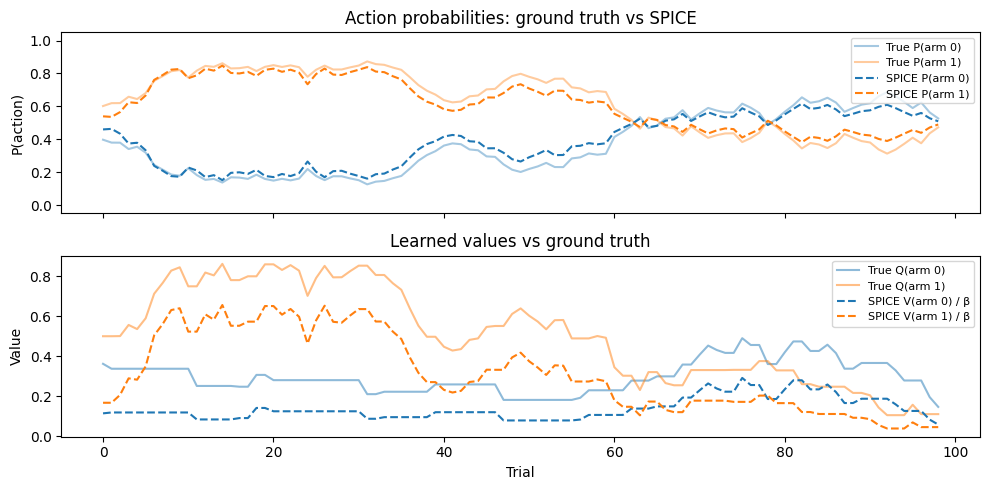

In [28]:
# Visualize predictions vs ground truth for one session
predictions = estimator_basic.predict(dataset_basic.xs)
# predictions shape: (sessions, trials, within_ts, n_actions) — raw logits

session_id = 0
logits = predictions[session_id, :, 0, :]  # (trials, n_actions)
# Convert to action probabilities
action_probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)

# Ground truth action probabilities from the agent's Q-values
Q_true = traj_basic['Q'][session_id]
logits_true = 3.0 * Q_true  # beta_reward=3.0
logits_true -= logits_true.max(axis=-1, keepdims=True)
probs_true = np.exp(logits_true) / np.exp(logits_true).sum(axis=-1, keepdims=True)

# SPICE predictions are shifted by 1 trial relative to ground truth:
# xs[t] = observation at trial t, so the model output at index t reflects
# the state *after* processing trial t (= agent state at t+1).
n = min(len(probs_true) - 1, len(action_probs))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Top: Action probabilities (SPICE vs ground truth)
ax = axes[0]
ax.plot(range(n), probs_true[1:n+1, 0], 'C0', alpha=0.4, label='True P(arm 0)')
ax.plot(range(n), probs_true[1:n+1, 1], 'C1', alpha=0.4, label='True P(arm 1)')
ax.plot(range(n), action_probs[:n, 0], 'C0--', label='SPICE P(arm 0)')
ax.plot(range(n), action_probs[:n, 1], 'C1--', label='SPICE P(arm 1)')
ax.set_ylabel('P(action)')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Action probabilities: ground truth vs SPICE')

# Bottom: Discovered values vs true Q-values
ax = axes[1]
ax.plot(range(n), Q_true[1:n+1, 0], 'C0', alpha=0.5, label='True Q(arm 0)')
ax.plot(range(n), Q_true[1:n+1, 1], 'C1', alpha=0.5, label='True Q(arm 1)')
ax.plot(range(n), logits[:n, 0] / 3.0, 'C0--', label='SPICE V(arm 0) / β')
ax.plot(range(n), logits[:n, 1] / 3.0, 'C1--', label='SPICE V(arm 1) / β')
ax.set_xlabel('Trial')
ax.set_ylabel('Value')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Learned values vs ground truth')

plt.tight_layout()
plt.show()

In [10]:
# Programmatic access to coefficients
coefficients = estimator_basic.get_sindy_coefficients(aggregate=True)
terms = estimator_basic.get_candidate_terms()

print(f"Candidate terms: {terms['reward_update_chosen']}")
print(f"Coefficients:    {coefficients['reward_update_chosen'][0, 0].numpy().round(3)}")

Candidate terms: ['1', 'reward_update_chosen', 'reward', 'reward_update_chosen^2', 'reward_update_chosen*reward', 'reward^2']
Coefficients:    [-0.143 -0.267  0.791  0.     0.     0.   ]


---
# Part 3: Adding Forgetting — Full Pipeline

In real decision-making, people forget the values of options they haven't chosen recently. We model this with a second submodule that handles the **unchosen** actions.

Forgetting equation: $V^{\text{unchosen}}_{t+1} = (1-f) \cdot V^{\text{unchosen}}_t + f \cdot V_0$

## 3.1 Generate Data with Forgetting

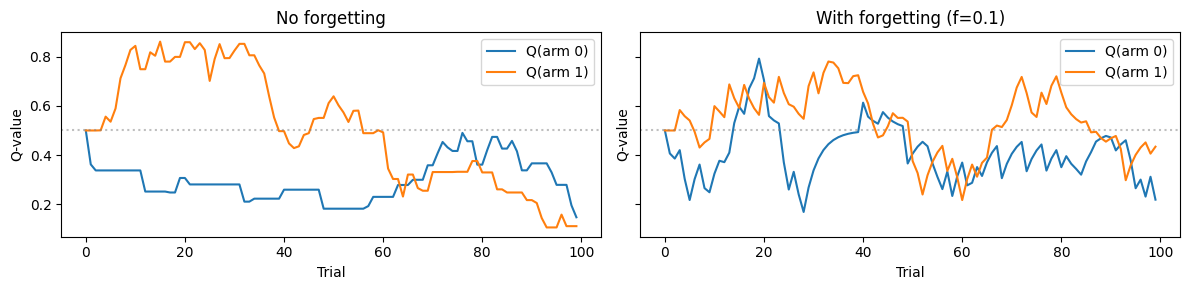

Notice: with forgetting, unchosen values drift back toward 0.5 (gray line).


In [ ]:
df_forget, traj_forget = simulate_bandit_qlearning(
    n_participants=100, n_blocks=5, n_trials=100,
    alpha_reward=0.3, beta_reward=3.0,
    forget_rate=0.3,   # <-- unchosen values drift back to 0.5
    drift_rate=0.2,
)

dataset_forget = csv_to_dataset(
    df_forget, df_participant_id='participant',
    df_block='block', df_choice='choice', df_feedback='reward',
)

# Visualize: compare Q-values with and without forgetting
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, Q, title in zip(axes, [traj_basic['Q'][0], traj_forget['Q'][0]], 
                          ['No forgetting', 'With forgetting (f=0.1)']):
    ax.plot(Q[:, 0], 'C0', label='Q(arm 0)')
    ax.plot(Q[:, 1], 'C1', label='Q(arm 1)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Q-value')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()
print("Notice: with forgetting, unchosen values drift back toward 0.5 (gray line).")

## 3.2 Implement the Model

The new module `reward_update_not_chosen`:
- Has **no control signals** (forgetting depends only on the current state)
- Updates the **unchosen** actions (`action_mask = 1 - actions`)
- Writes to the same `value_reward` state

In [30]:
config_forget = SpiceConfig(
    library_setup={
        'reward_update_chosen': ['reward'],
        'reward_update_not_chosen': [],  # No control signals — only depends on current state
    },
    memory_state={
        'value_reward': 0.5,
    },
)

class ForgettingRW(BaseModel):
    """Rescorla-Wagner + forgetting for unchosen actions."""
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.participant_embedding = self.setup_embedding(num_embeddings=self.n_participants)
        self.setup_modules_from_config()
    
    def forward(self, inputs, prev_state=None):
        spice_signals = self.init_forward_pass(inputs, prev_state)
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        
        for timestep in spice_signals.trials:
            # Update chosen action
            self.call_module(
                key_module='reward_update_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[timestep],
                inputs=spice_signals.feedback[timestep],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # Update unchosen actions (forgetting)
            self.call_module(
                key_module='reward_update_not_chosen',
                key_state='value_reward',
                action_mask=1 - spice_signals.actions[timestep],
                inputs=None,
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            spice_signals.logits[timestep] = self.state['value_reward']
        
        spice_signals = self.post_forward_pass(spice_signals)
        return spice_signals.logits, self.get_state()

## 3.3 Fit & Inspect

In [ ]:
estimator_forget = SpiceEstimator(
    spice_class=ForgettingRW, spice_config=config_forget,
    n_actions=dataset_forget.n_actions,
    n_participants=dataset_forget.n_participants,
    epochs=500, warmup_steps=250, learning_rate=1e-2, ensemble_size=10,
    sindy_weight=0.01, sindy_threshold_pruning=0.05, sindy_ensemble_pruning=0.7,
    verbose=True,
)
estimator_forget.fit(dataset_forget.xs, dataset_forget.ys)

100%|█████████████████████████████████████████████████████████████████████████| 500/500 [12:53<00:00,  1.55s/it, L(Train)=0.6461350, Conv=4.19e-05, LR=1.00e-02]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
SPICE Model (Coefficients: 5):
reward_update_chosen[t+1]     = -0.109 1 + 0.773 reward_update_chosen[t] + 0.53 reward 
reward_update_not_chosen[t+1] = 0.076 1 + 0.852 reward_update_not_chosen[t] 
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Pruning patience:
reward_update_chosen:     0, 0, 0, -, -, -
reward_update_not_chosen: 0, 0, -
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Term presence across SPICE models (number of models=100):
reward_

 10%|█         | 104/1000 [00:06<00:50, 17.66it/s, loss=0.0015861, lr=5.0e-03, n_params=9.00+/-0.00]

Ensemble confidence filtering:
	reward_update_chosen: 600 -> 341 / 600 (participant, experiment, term) slots
	reward_update_not_chosen: 300 -> 194 / 300 (participant, experiment, term) slots


 20%|██        | 204/1000 [00:12<00:49, 16.19it/s, loss=0.0025425, lr=1.0e-02, n_params=7.00+/-0.00]

Ensemble confidence filtering:
	reward_update_chosen: 600 -> 343 / 600 (participant, experiment, term) slots
	reward_update_not_chosen: 300 -> 193 / 300 (participant, experiment, term) slots


...

Ensemble confidence filtering:
	reward_update_chosen: 372 -> 372 / 600 (participant, experiment, term) slots
	reward_update_not_chosen: 196 -> 196 / 300 (participant, experiment, term) slots


100%|██████████| 1000/1000 [01:00<00:00, 16.60it/s, loss=0.0017374, lr=1.0e-05, n_params=5.68+/-0.55]



Stage 2.2: SINDy coefficient estimation (multi-step shooting, K=100)
Re-computing state trajectories on full data (per-member targets)...
Ridge regression succeeded (K=100 loss: 0.0072379). Running SGD refinement...


 25%|██▌       | 251/1000 [01:37<04:50,  2.58it/s, K=100, loss=0.0054411, lr=1.0e-05, n_params=5.68+/-0.55]



Stage 2.2 interrupted. Continuing...

Losses:
	         Training
	RNN      0.65128
	SINDy    0.65122

RNN training finished.
Training took 933.23 seconds.


In [32]:
print("Discovered equations:")
print("-" * 60)
estimator_forget.print_spice_model(participant_id=0)
print()
print("Expected:")
print(f"  reward_update_chosen[t+1]     \u2248 0.7*V[t] + 0.9*reward   (alpha=0.3, beta=3)")
print(f"  reward_update_not_chosen[t+1] \u2248 0.9*V[t] + constant     (1-f=0.9, f*V0*beta)")

Discovered equations:
------------------------------------------------------------
reward_update_chosen[t+1]     = -0.122 1 + 0.755 reward_update_chosen[t] + 0.643 reward 
reward_update_not_chosen[t+1] = 0.08 1 + 0.835 reward_update_not_chosen[t] 

Expected:
  reward_update_chosen[t+1]     ≈ 0.7*V[t] + 0.9*reward   (alpha=0.3, beta=3)
  reward_update_not_chosen[t+1] ≈ 0.9*V[t] + constant     (1-f=0.9, f*V0*beta)


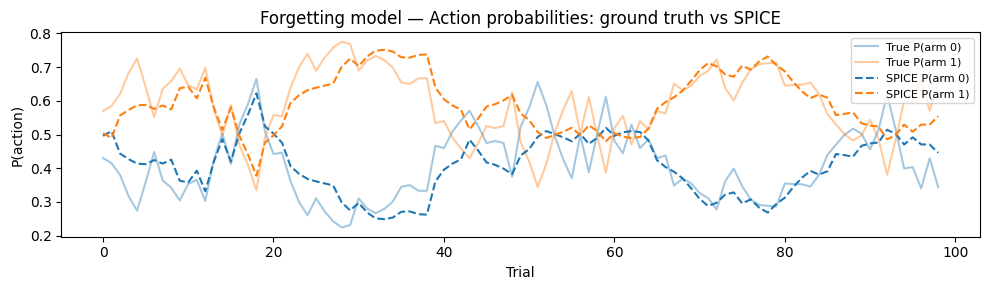

In [33]:
# Plot predictions vs ground truth
preds = estimator_forget.predict(dataset_forget.xs)
logits_f = preds[0, :, 0, :]
probs_f = np.exp(logits_f) / np.exp(logits_f).sum(axis=-1, keepdims=True)

# Ground truth action probabilities
Q_true = traj_forget['Q'][0]
logits_true = 3.0 * Q_true  # beta_reward=3.0
logits_true -= logits_true.max(axis=-1, keepdims=True)
probs_true = np.exp(logits_true) / np.exp(logits_true).sum(axis=-1, keepdims=True)

# Align: SPICE output at index t = agent state at t+1
n = min(len(probs_true) - 1, len(probs_f))

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(n), probs_true[1:n+1, 0], 'C0', alpha=0.4, label='True P(arm 0)')
ax.plot(range(n), probs_true[1:n+1, 1], 'C1', alpha=0.4, label='True P(arm 1)')
ax.plot(range(n), probs_f[:n, 0], 'C0--', label='SPICE P(arm 0)')
ax.plot(range(n), probs_f[:n, 1], 'C1--', label='SPICE P(arm 1)')
ax.set_xlabel('Trial')
ax.set_ylabel('P(action)')
ax.set_title('Forgetting model — Action probabilities: ground truth vs SPICE')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
# Part 4: Adding Choice Perseverance — Full Pipeline

Choice perseverance captures the tendency to **repeat previous actions** regardless of reward outcomes. We model this as a separate memory state that contributes to the logits additively.

Here we use a single `choice_update` module that receives the **choice** as input and updates **all** items at once (no action_mask needed):

$$C_{t+1} = (1 - \alpha_c) \cdot C_t + \alpha_c \cdot \text{choice}_t$$

Since `choice` is one-hot encoded (e.g., `[1, 0]` for arm 0), this naturally increases the value for the chosen arm and leaves the unchosen at its current decayed value.

## 4.1 Generate Data

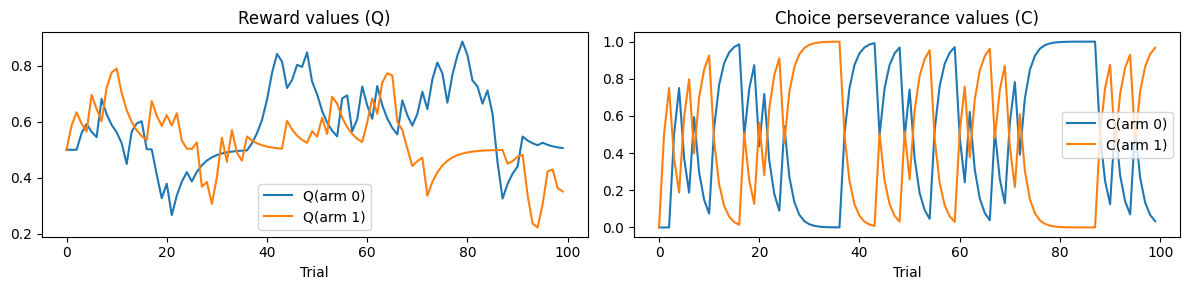

Choice perseverance creates a 'momentum' — recently chosen actions get a bonus.


In [6]:
df_full, traj_full = simulate_bandit_qlearning(
    n_participants=100, n_blocks=5, n_trials=100,
    alpha_reward=0.3, beta_reward=3.0,
    forget_rate=0.3,
    alpha_choice=0.5, beta_choice=1.5,  # <-- choice perseverance
    drift_rate=0.2,
)

dataset_full = csv_to_dataset(
    df_full, df_participant_id='participant',
    df_block='block', df_choice='choice', df_feedback='reward',
)

# Visualize the choice perseverance signal
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

ax = axes[0]
Q = traj_full['Q'][0]
ax.plot(Q[:, 0], 'C0', label='Q(arm 0)')
ax.plot(Q[:, 1], 'C1', label='Q(arm 1)')
ax.set_title('Reward values (Q)')
ax.set_xlabel('Trial')
ax.legend()

ax = axes[1]
C = traj_full['C'][0]
ax.plot(C[:, 0], 'C0', label='C(arm 0)')
ax.plot(C[:, 1], 'C1', label='C(arm 1)')
ax.set_title('Choice perseverance values (C)')
ax.set_xlabel('Trial')
ax.legend()

plt.tight_layout()
plt.show()
print("Choice perseverance creates a 'momentum' — recently chosen actions get a bonus.")

## 4.2 Implement the Model

Key differences from the reward modules:
- `action_mask=None` — updates all items simultaneously
- `inputs=spice_signals.actions[timestep]` — receives the choice as a control signal
- Writes to a separate state: `key_state='value_choice'`

In [7]:
config_full = SpiceConfig(
    library_setup={
        'reward_update_chosen': ['reward'],
        'reward_update_not_chosen': [],
        'choice_update': ['choice'],  # receives choice as control signal
    },
    memory_state={
        'value_reward': 0.5,
        'value_choice': 0.0,
    },
)

class FullRW(BaseModel):
    """Rescorla-Wagner + Forgetting + Choice Perseverance."""
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.participant_embedding = self.setup_embedding(num_embeddings=self.n_participants)
        self.setup_modules_from_config()
    
    def forward(self, inputs, prev_state=None):
        spice_signals = self.init_forward_pass(inputs, prev_state)
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        
        for timestep in spice_signals.trials:
            # Reward update for chosen action
            self.call_module(
                key_module='reward_update_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[timestep],
                inputs=spice_signals.feedback[timestep],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # Forgetting for unchosen actions
            self.call_module(
                key_module='reward_update_not_chosen',
                key_state='value_reward',
                action_mask=1 - spice_signals.actions[timestep],
                inputs=None,
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # Choice perseverance (updates all items at once)
            self.call_module(
                key_module='choice_update',
                key_state='value_choice',
                action_mask=None,
                inputs=spice_signals.actions[timestep],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # Logits = sum of reward and choice values
            spice_signals.logits[timestep] = self.state['value_reward'] + self.state['value_choice']
        
        spice_signals = self.post_forward_pass(spice_signals)
        return spice_signals.logits, self.get_state()

## 4.3 Fit & Inspect

In [ ]:
estimator_full = SpiceEstimator(
    spice_class=FullRW, spice_config=config_full,
    n_actions=dataset_full.n_actions,
    n_participants=dataset_full.n_participants,
    epochs=700, warmup_steps=350, learning_rate=1e-2, ensemble_size=10,
    sindy_weight=0.01, sindy_threshold_pruning=0.05, sindy_ensemble_pruning=0.7,
    verbose=True,
)

print("Fitting full model...")
estimator_full.fit(dataset_full.xs, dataset_full.ys)

 23%|████████████████▍                                                        | 158/700 [03:44<12:49,  1.42s/it, L(Train)=0.5051805, Conv=2.97e-05, LR=1.00e-02]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
SPICE Model (Coefficients: 12):
reward_update_chosen[t+1]     = 0.062 1 + 0.687 reward_update_chosen[t] + 0.476 reward + -0.031 reward_update_chosen*reward + 0.322 reward^2 
reward_update_not_chosen[t+1] = 0.007 1 + 0.673 reward_update_not_chosen[t] 
choice_update[t+1]            = -0.012 1 + 0.855 choice_update[t] + 0.103 choice + -0.088 choice_update*choice + 0.104 choice^2 
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Pruning patience:
reward_update_chosen:     0, 0, 0, -, 2, 0
reward_update_not_chosen: 0, 0, -
choice_update:            2, 2, 2, -, 2, 2

In [ ]:
print("Discovered equations:")
print("-" * 60)
estimator_full.print_spice_model()
print()
print("Expected structure:")
print("  reward_update_chosen[t+1]     ~ (1-alpha)*V[t] + alpha*beta_r*reward")
print("  reward_update_not_chosen[t+1] ~ (1-f)*V[t] + f*V0*beta_r")
print("  choice_update[t+1]            ~ (1-alpha_c)*C[t] + alpha_c*beta_c*choice")

Discovered equations:
------------------------------------------------------------
reward_update_chosen[t+1]     = 0.031 1 + 0.565 reward_update_chosen[t] + 0.996 reward 
reward_update_not_chosen[t+1] = -0.166 1 + 0.517 reward_update_not_chosen[t] + 0.063 reward_update_not_chosen^2 
choice_update[t+1]            = 0.781 choice_update[t] 

Expected structure:
  reward_update_chosen[t+1]     ~ (1-alpha)*V[t] + alpha*beta_r*reward
  reward_update_not_chosen[t+1] ~ (1-f)*V[t] + f*V0*beta_r
  choice_update[t+1]            ~ (1-alpha_c)*C[t] + alpha_c*beta_c*choice


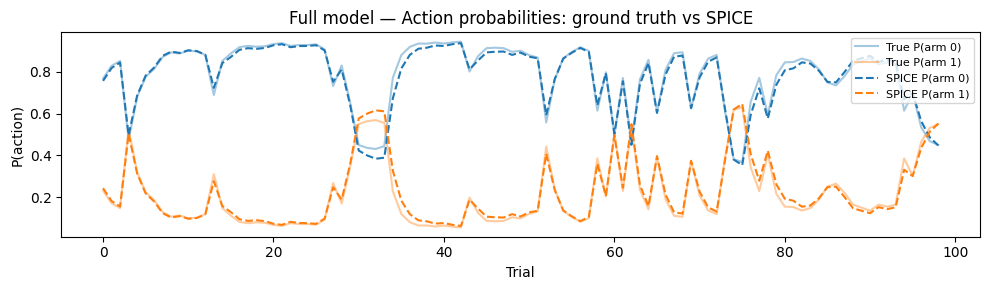

In [ ]:
# Plot predictions vs ground truth
preds = estimator_full.predict(dataset_full.xs)
logits_full = preds[0, :, 0, :]
probs_full = np.exp(logits_full) / np.exp(logits_full).sum(axis=-1, keepdims=True)

# Ground truth action probabilities (includes choice perseverance)
Q_true = traj_full['Q'][0]
C_true = traj_full['C'][0]
logits_true = 3.0 * Q_true + 1.5 * C_true  # beta_reward=3.0, beta_choice=1.5
logits_true -= logits_true.max(axis=-1, keepdims=True)
probs_true = np.exp(logits_true) / np.exp(logits_true).sum(axis=-1, keepdims=True)

# Align: SPICE output at index t = agent state at t+1
n = min(len(probs_true) - 1, len(probs_full))

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(n), probs_true[1:n+1, 0], 'C0', alpha=0.4, label='True P(arm 0)')
ax.plot(range(n), probs_true[1:n+1, 1], 'C1', alpha=0.4, label='True P(arm 1)')
ax.plot(range(n), probs_full[:n, 0], 'C0--', label='SPICE P(arm 0)')
ax.plot(range(n), probs_full[:n, 1], 'C1--', label='SPICE P(arm 1)')
ax.set_xlabel('Trial')
ax.set_ylabel('P(action)')
ax.set_title('Full model — Action probabilities: ground truth vs SPICE')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
# Part 5: Parameter Recovery with Mixed Agent Types

Finally, let's test whether SPICE can recover **structurally different** equations when the dataset contains multiple participants with different underlying mechanisms.

We'll create 30 participants:
- Participants 0\u20139: Basic RW only
- Participants 10\u201319: RW + Forgetting
- Participants 20\u201329: RW + Forgetting + Choice Perseverance

SPICE should discover different equation structures per participant.

In [ ]:
# Generate mixed dataset: 30 participants × 5 blocks each
dfs = []

for p in range(10):  # Basic RW
    df_p, _ = simulate_bandit_qlearning(
        n_participants=1, n_blocks=5, n_trials=100,
        alpha_reward=0.3, beta_reward=3.0)
    df_p['participant'] = p
    dfs.append(df_p)

for p in range(10, 20):  # + Forgetting
    df_p, _ = simulate_bandit_qlearning(
        n_participants=1, n_blocks=5, n_trials=100,
        alpha_reward=0.3, beta_reward=3.0, forget_rate=0.1)
    df_p['participant'] = p
    dfs.append(df_p)

for p in range(20, 30):  # + Choice Perseverance
    df_p, _ = simulate_bandit_qlearning(
        n_participants=1, n_blocks=5, n_trials=100,
        alpha_reward=0.3, beta_reward=3.0, forget_rate=0.1,
        alpha_choice=0.5, beta_choice=1.5)
    df_p['participant'] = p
    dfs.append(df_p)

df_mixed = pd.concat(dfs, ignore_index=True)
dataset_mixed = csv_to_dataset(df_mixed, df_participant_id='participant',
    df_block='block', df_choice='choice', df_feedback='reward')

print(f"Mixed dataset: {dataset_mixed.n_participants} participants, "
      f"{dataset_mixed.xs.shape[0]} sessions (blocks), "
      f"{dataset_mixed.xs.shape[1]} trials per session")

In [ ]:
# Fit the full architecture to the mixed dataset
estimator_mixed = SpiceEstimator(
    spice_class=FullRW, spice_config=config_full,
    n_actions=dataset_mixed.n_actions,
    n_participants=dataset_mixed.n_participants,
    epochs=700, learning_rate=1e-2, ensemble_size=10,
    sindy_weight=0.01, sindy_threshold_pruning=0.05, sindy_ensemble_pruning=0.7,
    verbose=True,
)

print("Fitting to mixed dataset (30 participants × 5 blocks, 3 agent types)...")
estimator_mixed.fit(dataset_mixed.xs, dataset_mixed.ys)

In [ ]:
# Compare equations across groups
print("Group 1 \u2014 Basic RW (participant 0):")
estimator_mixed.print_spice_model(participant_id=0)
print()
print("Group 2 \u2014 + Forgetting (participant 10):")
estimator_mixed.print_spice_model(participant_id=10)
print()
print("Group 3 \u2014 + Choice Perseverance (participant 20):")
estimator_mixed.print_spice_model(participant_id=20)

In [ ]:
# Visualize structural differences across participants
coefficients_mixed = estimator_mixed.get_sindy_coefficients(aggregate=True)
modules = estimator_mixed.get_modules()

active_per_participant = np.zeros((dataset_mixed.n_participants, len(modules)))
for m_idx, module in enumerate(modules):
    coefs = coefficients_mixed[module][:, 0].numpy()  # (P, terms)
    active_per_participant[:, m_idx] = (np.abs(coefs) > 1e-6).sum(axis=-1)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
im = ax.imshow(active_per_participant.T, aspect='auto', cmap='Blues', vmin=0)
ax.set_xlabel('Participant')
ax.set_yticks(range(len(modules)))
ax.set_yticklabels(modules, fontsize=9)
ax.set_title('Active SINDy terms per module per participant')
ax.axvline(9.5, color='red', linestyle='--', linewidth=1.5)
ax.axvline(19.5, color='red', linestyle='--', linewidth=1.5)
plt.colorbar(im, ax=ax, label='# active terms')
plt.tight_layout()
plt.show()
print("Red lines separate groups: Basic RW | + Forgetting | + Choice Perseverance")
print("Expectation: choice_update should only be active for participants 20-29.")

## 5.1 Interpret the results

**Questions:**

1. Does SPICE correctly identify that Group 1 participants have no forgetting?
2. Does SPICE correctly identify that Groups 1 and 2 have no choice perseverance?
3. Are the recovered learning rates consistent across groups?
4. **Bonus:** What happens if you fit `BasicRW` (too simple architecture) to the full dataset?

In [ ]:
# Bonus: fit an under-specified model
estimator_underfit = SpiceEstimator(
    spice_class=BasicRW, spice_config=config_basic,
    n_actions=dataset_full.n_actions, n_participants=dataset_full.n_participants,
    epochs=500, ensemble_size=10,
    sindy_weight=0.01, sindy_threshold_pruning=0.05, sindy_ensemble_pruning=0.7,
    verbose=True,
)
estimator_underfit.fit(dataset_full.xs, dataset_full.ys)
print("\nDiscovered equation (under-specified model):")
estimator_underfit.print_spice_model()

---
# Summary

### What we covered:

| Concept | Key takeaway |
|---------|--------------|
| **Data pipeline** | `DataFrame` \u2192 `csv_to_dataset()` \u2192 `SpiceDataset` |
| **SpiceConfig** | Defines modules, their inputs, and memory states |
| **BaseModel** | `setup_modules_from_config()` + `call_module()` in a trial loop |
| **action_mask** | Controls which items get updated (chosen vs unchosen vs all) |
| **Ensemble** | Multiple RNNs trained in parallel for robust pruning |
| **Equations** | Discovered in logit space (scaled by $\beta$) |
| **Individual differences** | Per-participant SINDy coefficients reveal structural variations |

### Key design principle:

The model architecture defines the **hypothesis space**. SPICE searches within it, using sparsification to find the simplest equations that explain the data. A more complex architecture can always discover simpler equations (by pruning terms to zero).

### Next steps:
- Try **asymmetric learning rates** ($\alpha_{\text{reward}} \neq \alpha_{\text{penalty}}$) with `polynomial_degree=2`
- Explore `setup_module(..., polynomial_degree=2)` for nonlinear interactions
- Apply SPICE to real behavioral datasets
- See the [SPICE documentation](https://whyhardt.github.io/SPICE/) for advanced features